In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.font_manager import fontManager, FontProperties


try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

df_path = "/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/Datasets/new_data.csv"
df = pd.read_csv(df_path)

PALETTE = ["#5e17eb", "#ff6b6b", "#00c49a"]
FONT_CANDIDATES = [
    "/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/HSE_FONTS_FOR_GRAPHS_copy/HSESlab-Regular.ttf",
    "/Users/royalmustaches/Documents/Programming/Dano/DANO_NES_2026/HSE_FONTS_FOR_GRAPHS/HSESlab-Regular.ttf",
    "/Users/royalmustaches/Documents/Programming/Dano/Practice/Organization/Fonts_for_projects/HSESlab-Regular.ttf",
]

FONT_NAME = "DejaVu Sans"
for font_path in FONT_CANDIDATES:
    if os.path.exists(font_path):
        fontManager.addfont(font_path)
        FONT_NAME = FontProperties(fname=font_path).get_name()
        break

sns.set_theme(style="whitegrid", font=FONT_NAME, context="notebook", palette=PALETTE)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["grid.linestyle"] = "--"

PRIMARY = "#5e17eb"
SECONDARY = "#ff6b6b"
ACCENT = "#00c49a"

In [2]:
import numpy as np

df["revenue_to_gmv_markup"] = np.where(
    df["gmv_with_markup"].notna() & (df["gmv_with_markup"] != 0),
    df["revenue"] / df["gmv_with_markup"],
    np.nan
)

                            OLS Regression Results                            
Dep. Variable:          revenue_share   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     1367.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:48:45   Log-Likelihood:             1.4039e+05
No. Observations:               89905   AIC:                        -2.808e+05
Df Residuals:                   89900   BIC:                        -2.807e+05
Df Model:                           4                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0606      0.000    144.978

,term,coef_pp,std_err_pp,z,p_value,ci_low_pp,ci_high_pp
0,Intercept,6.061164,0.041807,144.978148,0.000000e+00,5.979223,6.143105
1,cb_percent,-0.101738,0.003985,-25.528252,9.576534e-144,-0.109549,-0.093927
2,cb_x_markup_1,0.021779,0.004028,5.406895,6.412667e-08,0.013884,0.029673
3,cb_x_markup_5,0.153891,0.004992,30.829057,1.069314e-208,0.144107,0.163675
4,cb_x_markup_9,0.271870,0.004123,65.943266,0.000000e+00,0.263789,0.279950


<Wald test (chi2): statistic=[[5438.95787416]], p-value=0.0, df_denom=3>


,cb_percent,cb_x_markup_1,cb_x_markup_5,cb_x_markup_9
cb_percent,1.000000,0.300662,0.303325,0.293226
cb_x_markup_1,0.300662,1.000000,-0.196960,-0.194302
cb_x_markup_5,0.303325,-0.196960,1.000000,-0.191421
cb_x_markup_9,0.293226,-0.194302,-0.191421,1.000000


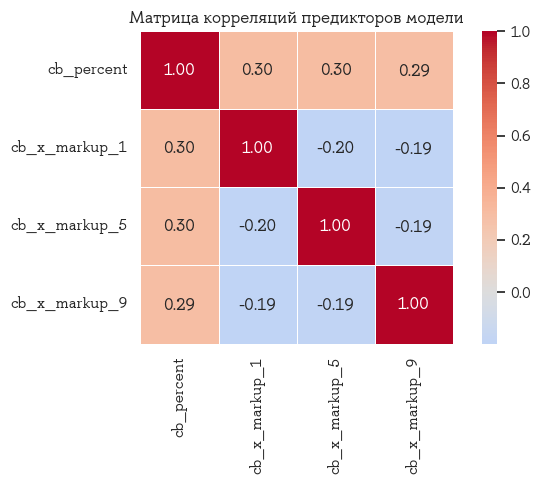

,variable,VIF
1,cb_percent,1.782024
3,cb_x_markup_5,1.535707
2,cb_x_markup_1,1.535119
4,cb_x_markup_9,1.517872


,cb_percent,markup,markup_1,markup_5,markup_9,cb_x_markup_1,cb_x_markup_5,cb_x_markup_9,predicted_revenue_share,ci_low,ci_high,predicted_revenue_share_pp,ci_low_pp,ci_high_pp
0,0.000000,0,0,0,0,0.0,0.0,0.000000,0.060612,0.059792,0.061431,6.061164,5.979223,6.143105
1,0.000000,1,1,0,0,0.0,0.0,0.000000,0.060612,0.059792,0.061431,6.061164,5.979223,6.143105
2,0.000000,5,0,1,0,0.0,0.0,0.000000,0.060612,0.059792,0.061431,6.061164,5.979223,6.143105
3,0.000000,9,0,0,1,0.0,0.0,0.000000,0.060612,0.059792,0.061431,6.061164,5.979223,6.143105
4,0.252525,0,0,0,0,0.0,0.0,0.000000,0.060355,0.059549,0.061160,6.035473,5.954924,6.116022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,24.747475,9,0,0,1,0.0,0.0,24.747475,0.102715,0.101090,0.104340,10.271501,10.108953,10.434049
396,25.000000,0,0,0,0,0.0,0.0,0.000000,0.035177,0.033692,0.036663,3.517721,3.369176,3.666265
397,25.000000,1,1,0,0,25.0,0.0,0.000000,0.040622,0.039021,0.042223,4.062190,3.902119,4.222260
398,25.000000,5,0,1,0,0.0,25.0,0.000000,0.073650,0.071421,0.075879,7.364996,7.142093,7.587898


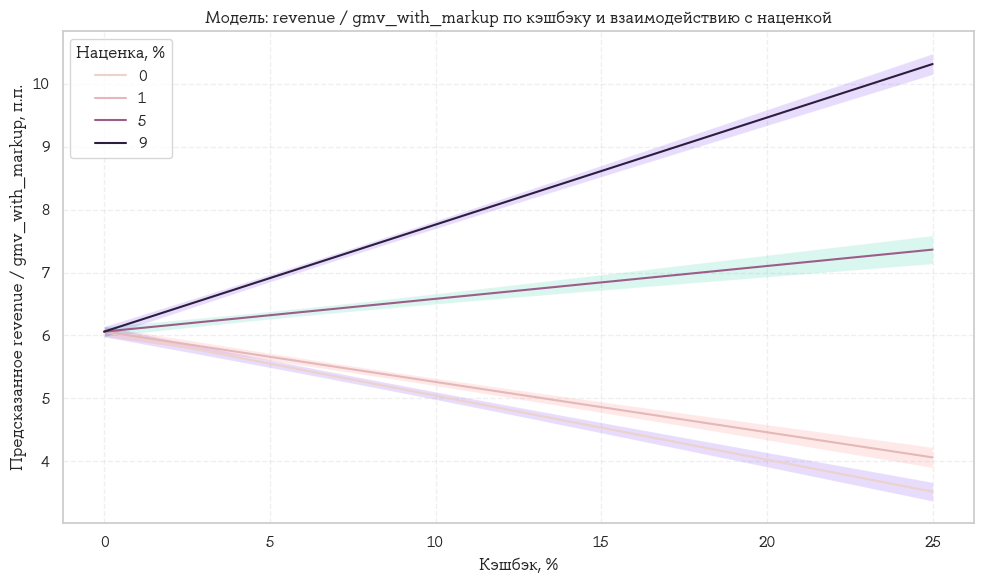

In [17]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# =========================
# 1. Подготовка данных
# =========================

df_model = df.copy()

df_model.columns = (
    df_model.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

# Целевая переменная
df_model = df_model[df_model['gmv_with_markup'] > 0].copy()
df_model['revenue_share'] = df_model['revenue'] / df_model['gmv_with_markup']

# Оставляем только нужные наблюдения
df_model = df_model.dropna(
    subset=[
        'revenue_share',
        'markup',
        'cb_percent'
    ]
).copy()

# Оставляем только нужные уровни наценки
df_model = df_model[df_model['markup'].isin([0, 1, 5, 9])].copy()
df_model['markup'] = df_model['markup'].astype(int)

# =========================
# 2. Флаги наценки
# =========================
# ВАЖНО:
# сами флаги markup_1, markup_5, markup_9 НЕ включаем в модель отдельно.
# Они нужны только для взаимодействий с cb_percent.

df_model['markup_1'] = (df_model['markup'] == 1).astype(int)
df_model['markup_5'] = (df_model['markup'] == 5).astype(int)
df_model['markup_9'] = (df_model['markup'] == 9).astype(int)

# =========================
# 3. Взаимодействия cb_percent × markup_flag
# =========================

df_model['cb_x_markup_1'] = df_model['cb_percent'] * df_model['markup_1']
df_model['cb_x_markup_5'] = df_model['cb_percent'] * df_model['markup_5']
df_model['cb_x_markup_9'] = df_model['cb_percent'] * df_model['markup_9']

# =========================
# 4. Линейная регрессия
# =========================

formula = """
revenue_share ~ cb_percent
              + cb_x_markup_1
              + cb_x_markup_5
              + cb_x_markup_9
"""

if 'client_id' in df_model.columns:
    model_cb_only = smf.ols(
        formula=formula,
        data=df_model
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_model['client_id']}
    )
else:
    model_cb_only = smf.ols(
        formula=formula,
        data=df_model
    ).fit(cov_type='HC3')

print(model_cb_only.summary())

# =========================
# 5. Таблица коэффициентов в процентных пунктах
# =========================

coef_table_cb_only = model_cb_only.summary2().tables[1].reset_index()
coef_table_cb_only = coef_table_cb_only.rename(columns={'index': 'term'})

for col in ['Coef.', 'Std.Err.', '[0.025', '0.975]']:
    coef_table_cb_only[col] = coef_table_cb_only[col] * 100

coef_table_cb_only = coef_table_cb_only.rename(columns={
    'Coef.': 'coef_pp',
    'Std.Err.': 'std_err_pp',
    '[0.025': 'ci_low_pp',
    '0.975]': 'ci_high_pp',
    'P>|z|': 'p_value'
})

display(coef_table_cb_only)

# =========================
# 6. Совместный тест взаимодействий
# =========================

print(
    model_cb_only.wald_test(
        'cb_x_markup_1 = 0, cb_x_markup_5 = 0, cb_x_markup_9 = 0'
    )
)

# =========================
# 7. Матрица корреляций предикторов
# =========================

predictors_cb_only = [
    'cb_percent',
    'cb_x_markup_1',
    'cb_x_markup_5',
    'cb_x_markup_9'
]

X_cb_only = df_model[predictors_cb_only].dropna().copy()

corr_matrix_cb_only = X_cb_only.corr()

display(corr_matrix_cb_only)

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix_cb_only,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Матрица корреляций предикторов модели')
plt.tight_layout()
plt.show()

# =========================
# 8. VIF
# =========================

X_vif_cb_only = sm.add_constant(X_cb_only)

vif_table_cb_only = pd.DataFrame({
    'variable': X_vif_cb_only.columns,
    'VIF': [
        variance_inflation_factor(X_vif_cb_only.values, i)
        for i in range(X_vif_cb_only.shape[1])
    ]
})

vif_table_cb_only = vif_table_cb_only[vif_table_cb_only['variable'] != 'const'].copy()
vif_table_cb_only = vif_table_cb_only.sort_values('VIF', ascending=False)

display(vif_table_cb_only)

# =========================
# 9. Предсказания для графика
# =========================
# Для непрерывного cb_percent строим сетку значений
# от 1-го до 99-го процентиля, чтобы не растягивать график выбросами.

cb_min = df_model['cb_percent'].quantile(0.01)
cb_max = df_model['cb_percent'].quantile(0.99)

cb_grid = np.linspace(cb_min, cb_max, 100)

pred_grid = pd.DataFrame([
    {
        'cb_percent': cb,
        'markup': markup
    }
    for cb in cb_grid
    for markup in [0, 1, 5, 9]
])

pred_grid['markup_1'] = (pred_grid['markup'] == 1).astype(int)
pred_grid['markup_5'] = (pred_grid['markup'] == 5).astype(int)
pred_grid['markup_9'] = (pred_grid['markup'] == 9).astype(int)

pred_grid['cb_x_markup_1'] = pred_grid['cb_percent'] * pred_grid['markup_1']
pred_grid['cb_x_markup_5'] = pred_grid['cb_percent'] * pred_grid['markup_5']
pred_grid['cb_x_markup_9'] = pred_grid['cb_percent'] * pred_grid['markup_9']

pred = model_cb_only.get_prediction(pred_grid).summary_frame(alpha=0.05)

pred_grid['predicted_revenue_share'] = pred['mean']
pred_grid['ci_low'] = pred['mean_ci_lower']
pred_grid['ci_high'] = pred['mean_ci_upper']

pred_grid['predicted_revenue_share_pp'] = pred_grid['predicted_revenue_share'] * 100
pred_grid['ci_low_pp'] = pred_grid['ci_low'] * 100
pred_grid['ci_high_pp'] = pred_grid['ci_high'] * 100

display(pred_grid)

# =========================
# 10. Визуализация модели
# =========================

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=pred_grid,
    x='cb_percent',
    y='predicted_revenue_share_pp',
    hue='markup'
)

for markup_value in [0, 1, 5, 9]:
    temp = pred_grid[pred_grid['markup'] == markup_value]

    plt.fill_between(
        temp['cb_percent'],
        temp['ci_low_pp'],
        temp['ci_high_pp'],
        alpha=0.15
    )

plt.title('Модель: revenue / gmv_with_markup по кэшбэку и взаимодействию с наценкой')
plt.xlabel('Кэшбэк, %')
plt.ylabel('Предсказанное revenue / gmv_with_markup, п.п.')
plt.legend(title='Наценка, %')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import statsmodels.formula.api as smf

df_model = df.copy()
df_model.columns = df_model.columns.str.replace('\ufeff', '', regex=False).str.strip()

df_model = df_model.query("gmv_with_markup > 0 and markup in [0, 1, 5, 9]").copy()
df_model["revenue_share"] = df_model["revenue"] / df_model["gmv_with_markup"]
df_model["cb_percent"] = pd.to_numeric(df_model["cb_percent"], errors="coerce")

df_model = df_model.dropna(subset=["revenue_share", "markup", "cb_percent"])
df_model["markup"] = df_model["markup"].astype(int)

for m in [1, 5, 9]:
    df_model[f"cb_x_markup_{m}"] = df_model["cb_percent"] * (df_model["markup"] == m).astype(int)

formula = "revenue_share ~ cb_percent + cb_x_markup_1 + cb_x_markup_5 + cb_x_markup_9"

model_cb_only = smf.ols(formula, data=df_model).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_model["client_id"]}
) if "client_id" in df_model.columns else smf.ols(formula, data=df_model).fit(cov_type="HC3")

print(model_cb_only.summary())

                            OLS Regression Results                            
Dep. Variable:          revenue_share   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     1367.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:57:35   Log-Likelihood:             1.4039e+05
No. Observations:               89905   AIC:                        -2.808e+05
Df Residuals:                   89900   BIC:                        -2.807e+05
Df Model:                           4                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0606      0.000    144.978

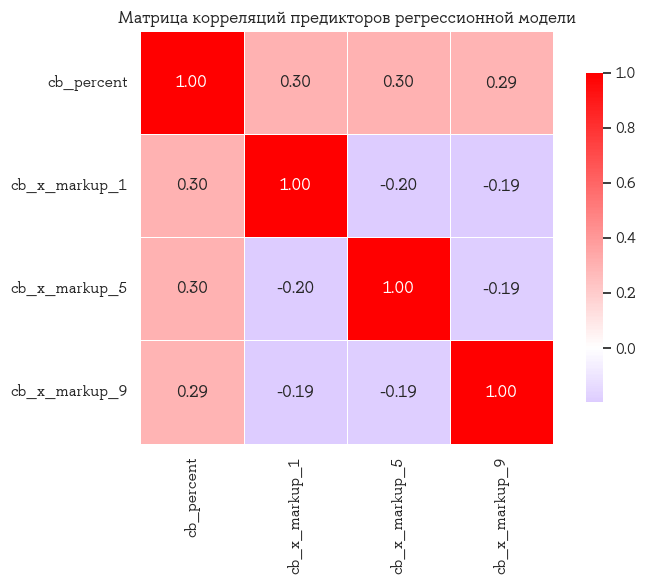

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# =========================
# 1. Подготовка данных
# =========================

reg_df = df.copy()

reg_df.columns = (
    reg_df.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

reg_df = reg_df[
    (reg_df["gmv_with_markup"] > 0) &
    (reg_df["markup"].isin([0, 1, 5, 9]))
].copy()

reg_df["revenue_share"] = reg_df["revenue"] / reg_df["gmv_with_markup"]

reg_df["markup"] = pd.to_numeric(reg_df["markup"], errors="coerce")
reg_df["cb_percent"] = pd.to_numeric(reg_df["cb_percent"], errors="coerce")
reg_df["revenue_share"] = pd.to_numeric(reg_df["revenue_share"], errors="coerce")

reg_df = reg_df.replace([np.inf, -np.inf], np.nan)
reg_df = reg_df.dropna(subset=["revenue_share", "markup", "cb_percent"])

reg_df["markup"] = reg_df["markup"].astype(int)

# =========================
# 2. Базовая группа: markup = 0
# =========================

reg_df["markup_1"] = (reg_df["markup"] == 1).astype(int)
reg_df["markup_5"] = (reg_df["markup"] == 5).astype(int)
reg_df["markup_9"] = (reg_df["markup"] == 9).astype(int)

# =========================
# 3. Интеракции cashback × markup
# =========================

reg_df["cb_x_markup_1"] = reg_df["cb_percent"] * reg_df["markup_1"]
reg_df["cb_x_markup_5"] = reg_df["cb_percent"] * reg_df["markup_5"]
reg_df["cb_x_markup_9"] = reg_df["cb_percent"] * reg_df["markup_9"]

# =========================
# 4. Предикторы именно из модели
# =========================

cols_for_heatmap = [
    "cb_percent",
    "cb_x_markup_1",
    "cb_x_markup_5",
    "cb_x_markup_9",
]

corr = reg_df[cols_for_heatmap].corr(numeric_only=True)

# =========================
# 5. Цветовая карта
# =========================

COLORS = ["#5500ff", "#ffffff", "#ff0000"]
cmap = LinearSegmentedColormap.from_list("custom_cmap", COLORS)

# =========================
# 6. Heatmap
# =========================

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap=cmap,
    linewidths=0.5,
    fmt=".2f",
    square=True,
    center=0,
    cbar_kws={"shrink": 0.8}
)

plt.title("Матрица корреляций предикторов регрессионной модели")
plt.tight_layout()
plt.show()

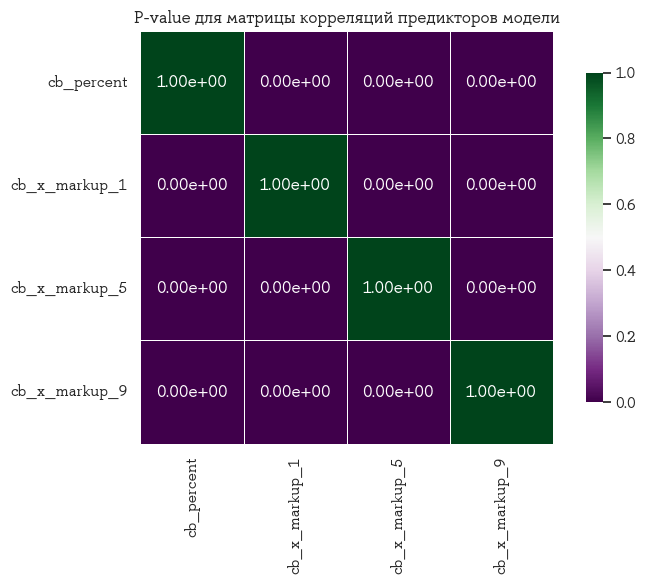

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st

# =========================
# 1. Подготовка данных
# =========================

reg_df = df.copy()

reg_df.columns = (
    reg_df.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

reg_df = reg_df[
    (reg_df["gmv_with_markup"] > 0) &
    (reg_df["markup"].isin([0, 1, 5, 9]))
].copy()

reg_df["revenue_share"] = reg_df["revenue"] / reg_df["gmv_with_markup"]

reg_df["markup"] = pd.to_numeric(reg_df["markup"], errors="coerce")
reg_df["cb_percent"] = pd.to_numeric(reg_df["cb_percent"], errors="coerce")
reg_df["revenue_share"] = pd.to_numeric(reg_df["revenue_share"], errors="coerce")

reg_df = reg_df.replace([np.inf, -np.inf], np.nan)
reg_df = reg_df.dropna(subset=["revenue_share", "markup", "cb_percent"])

reg_df["markup"] = reg_df["markup"].astype(int)

# =========================
# 2. Базовая группа: markup = 0
# =========================

reg_df["markup_1"] = (reg_df["markup"] == 1).astype(int)
reg_df["markup_5"] = (reg_df["markup"] == 5).astype(int)
reg_df["markup_9"] = (reg_df["markup"] == 9).astype(int)

# =========================
# 3. Интеракции cashback × markup
# =========================

reg_df["cb_x_markup_1"] = reg_df["cb_percent"] * reg_df["markup_1"]
reg_df["cb_x_markup_5"] = reg_df["cb_percent"] * reg_df["markup_5"]
reg_df["cb_x_markup_9"] = reg_df["cb_percent"] * reg_df["markup_9"]

# =========================
# 4. Предикторы модели
# =========================

cols_for_pval = [
    "cb_percent",
    "cb_x_markup_1",
    "cb_x_markup_5",
    "cb_x_markup_9",
]

# =========================
# 5. Функция для p-value корреляции Пирсона
# =========================

def pearsonr_pval(x, y):
    x = pd.Series(x)
    y = pd.Series(y)

    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]

    if x.nunique() <= 1 or y.nunique() <= 1:
        return np.nan

    return st.pearsonr(x, y)[1]

# =========================
# 6. Матрица p-value
# =========================

pval_matrix = reg_df[cols_for_pval].corr(method=pearsonr_pval)

# Диагональ вручную ставим в 0,
# потому что pandas для corr() обычно ставит 1 на диагональ
# =========================
# 7. Heatmap
# =========================

plt.figure(figsize=(8, 6))

sns.heatmap(
    pval_matrix,
    annot=True,
    cmap="PRGn",
    linewidths=0.5,
    fmt=".2e",
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("P-value для матрицы корреляций предикторов модели")
plt.tight_layout()
plt.show()